# Customer Purchese Prediction: KNN vs Decision Tree

### A Comparative Analysis of Distance-Based and Tree-Based Models

## This project compares the performance of K-Nearest Neighbors and Decision Tree classifiers for predicting customer purchase behavior.
Created by: Yasin Dehghani


## import the libraries for Decision Tree

In [14]:
import pandas as pd 
import numpy as np
from sklearn.tree import DecisionTreeClassifier

### The dataset used in this project is included in the repository

In [15]:
df=pd.read_csv('knn_vs_decision_tree_dataset.csv')
df.head()

,Age,Annual_Income,Spending_Score,Online_Visits_Per_Month,Loyalty_Member,Purchased
0,56,58467,12,4,1,0
1,46,43328,61,17,0,0
2,32,111412,19,27,1,0
3,60,106831,76,41,1,1
4,25,23987,9,21,0,0


## Exploratory Data Analysis

In [16]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 6 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   Age                      300 non-null    int64
 1   Annual_Income            300 non-null    int64
 2   Spending_Score           300 non-null    int64
 3   Online_Visits_Per_Month  300 non-null    int64
 4   Loyalty_Member           300 non-null    int64
 5   Purchased                300 non-null    int64
dtypes: int64(6)
memory usage: 14.2 KB


,Age,Annual_Income,Spending_Score,Online_Visits_Per_Month,Loyalty_Member,Purchased
count,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000
mean,40.810000,71254.183333,49.456667,23.963333,0.486667,0.296667
std,13.547164,29232.219829,28.829590,14.537760,0.500657,0.457552
min,18.000000,20301.000000,1.000000,0.000000,0.000000,0.000000
25%,29.000000,46503.750000,24.750000,10.000000,0.000000,0.000000
50%,41.500000,71937.500000,51.000000,25.000000,0.000000,0.000000
75%,52.000000,96267.000000,74.250000,36.000000,1.000000,1.000000
max,64.000000,119713.000000,99.000000,49.000000,1.000000,1.000000


## Feature and Target Separation

In this step, we separate the independent variables (features) from the dependent variable (target).

The goal is to use customer information to predict whether a purchase was made.

In [17]:
x=df.drop('Purchased', axis=1).values
y=df['Purchased']

print('Features shape:', x.shape)
print('Features shape:', y.shape)

Features shape: (300, 5)
Features shape: (300,)


### The dataset contains 5 input features and 1 binary target variable.

## Craeting Train & Test Dataset

In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split( x, y, test_size=0.2, random_state=42)

## Building model

In [19]:
dtc=DecisionTreeClassifier(criterion='entropy', max_depth=4)
dtc.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'entropy'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",4
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

## Model Evaluation

To evaluate the performance of the Decision Tree classifier, we use classification metrics including:

- Accuracy Score
- Confusion Matrix
- Precision, Recall, and F1-score

These metrics help us understand how well the model performs on unseen test data.

In [20]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

y_pred = dtc.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.9333333333333333

Confusion Matrix:
 [[38  0]
 [ 4 18]]

Classification Report:
               precision    recall  f1-score   support

           0       0.90      1.00      0.95        38
           1       1.00      0.82      0.90        22

    accuracy                           0.93        60
   macro avg       0.95      0.91      0.93        60
weighted avg       0.94      0.93      0.93        60



The model achieved an accuracy of 0.93, meaning it correctly predicted 93% of the test samples.

The confusion matrix shows how many instances were correctly and incorrectly classified.

## Decision Tree Visualization

To better understand how the Decision Tree makes decisions, we visualize the tree structure.

Each node represents a decision rule based on a feature.
The tree splits the data recursively to classify customers as purchasers or non-purchasers.

The visualization helps interpret the model and understand which features are most important.

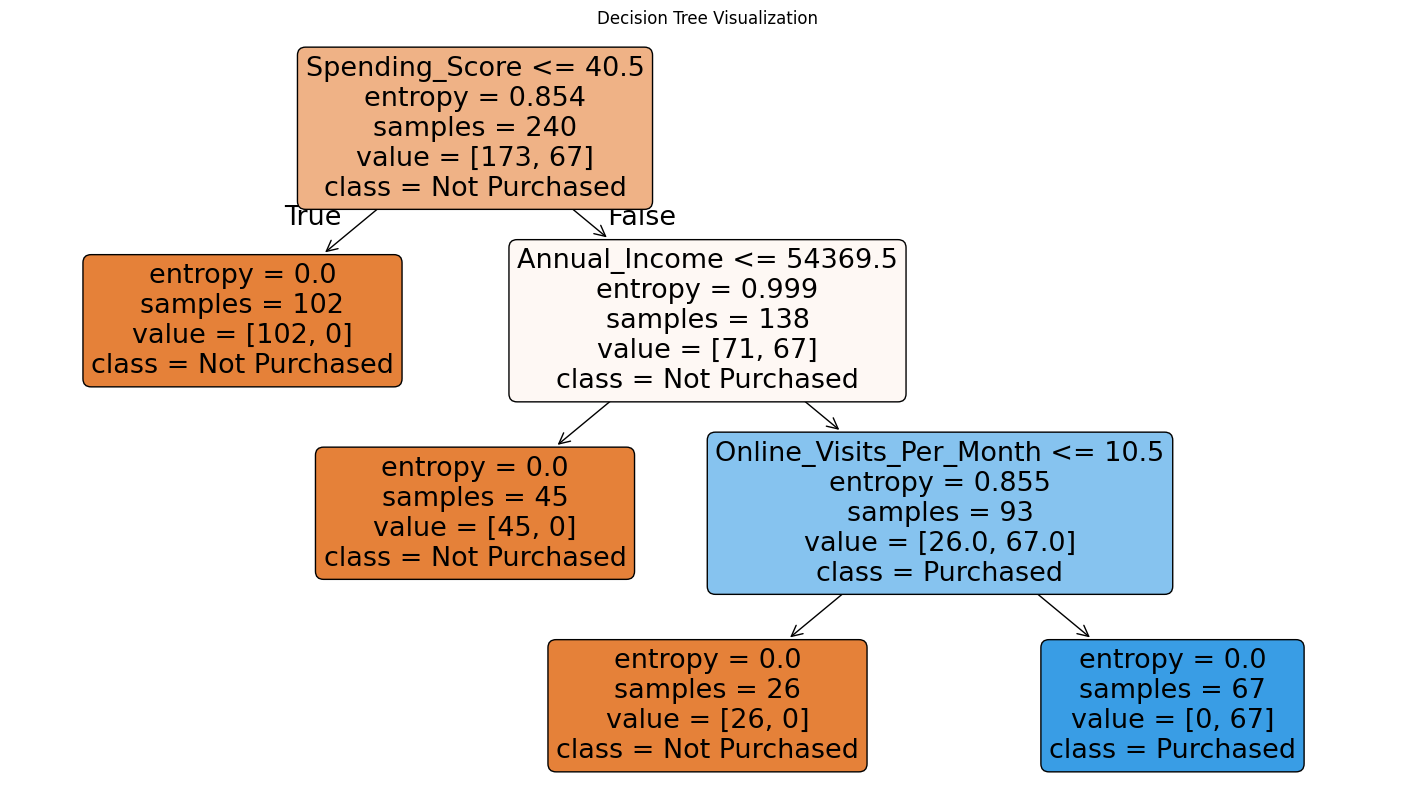

In [33]:
features=df.drop('Purchased', axis=1).columns

from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(18,10))

plot_tree(
    dtc,
    feature_names=features,
    class_names=["Not Purchased", "Purchased"],
    filled=True,
    rounded=True
)

plt.title("Decision Tree Visualization")
plt.savefig("decision_tree.png")
plt.show()

## import libraries for KNN

In [21]:
import matplotlib.pyplot as plt

## Feature Scaling for KNN

Since K-Nearest Neighbors is a distance-based algorithm, feature scaling is essential.

We use StandardScaler to normalize the features so that each variable has:
- Mean = 0
- Standard Deviation = 1

The scaler is fitted only on the training data to prevent data leakage.

In [23]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

X_train_scaled=scaler.fit_transform(X_train)

X_test_scaled=scaler.transform(X_test)

## K-Nearest Neighbors (KNN) Model

K-Nearest Neighbors is a distance-based classification algorithm.

The model classifies a new data point based on the majority class of its K nearest neighbors.

We use K = 5 in this experiment.

In [24]:
from sklearn.neighbors import KNeighborsClassifier

knn=KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train_scaled, y_train)

y_pred_knn=knn.predict(X_test_scaled)

## Model Evaluation

To evaluate the performance of the model, we use several classification metrics:

- Accuracy: Measures the overall percentage of correct predictions.
- Confusion Matrix: Shows the number of correct and incorrect predictions for each class.
- Precision: Measures how many predicted positive cases were actually correct.
- Recall: Measures how many actual positive cases were correctly identified.
- F1-Score: The harmonic mean of precision and recall.

These metrics provide a comprehensive understanding of the model's performance on unseen test data.

In [25]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))
print("\nConfusion matrix: \n", confusion_matrix(y_test, y_pred_knn))
print("\nClassification Report: \n", classification_report(y_test, y_pred_knn))

KNN Accuracy: 0.85

Confusion matrix: 
 [[37  1]
 [ 8 14]]

Classification Report: 
               precision    recall  f1-score   support

           0       0.82      0.97      0.89        38
           1       0.93      0.64      0.76        22

    accuracy                           0.85        60
   macro avg       0.88      0.81      0.82        60
weighted avg       0.86      0.85      0.84        60



The KNN model achieved an accuracy of 0.85 on the test set.

The confusion matrix indicates that the model performs well in identifying customers who are likely to purchase, with relatively few false positives.

The F1-score suggests a balanced performance between precision and recall.

## Conclusion

Decision Tree outperforms KNN in terms of accuracy on this dataset (0.93 vs 0.85). 

However, KNN is easier to implement and can generalize well if the data is properly scaled. 

For real-world deployment where interpretability is important, Decision Tree is recommended, while KNN might be preferred for smaller datasets or when simplicity is needed.